# ScanVI label transfer

In [ ]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

12/02 removed these:
* (adata_concat.obs["total_counts"] < 800))
* max_epochs = 20; now default settings
* overnight change - no max epochs, removed transgene version of dataset

In [1]:
from pathlib import Path
import os
import scanpy as sc
from scipy.sparse import issparse
import scvi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import anndata as ad
from lightning.pytorch import seed_everything
import random
import torch
import sys
import session_info

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
random.seed(0)
seed_everything(0)

scvi.settings.seed = 0
scvi.settings.num_workers = 32

Seed set to 0
Seed set to 0


In [3]:
base_dir = Path('/home/workspace/projects/drg')

adata_dir = base_dir / "data/h5ad/export_02/02b_leiden"
ref_data_dir = '/home/workspace/private/projects/kim/drg/data/scrna-seq/h5ad/05_reference' # Concatenated dataset

output_dir = base_dir / "data/h5ad/export_03/03a_scanvi"
scanvi_dir = base_dir / 'scanvi' # csv output
scvi_dir = base_dir / 'scvi/scanvi'

scanvi_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

In [4]:
adata = sc.read_h5ad(os.path.join(adata_dir, 'adata-leiden-475.h5ad'))
refdata = sc.read_h5ad(os.path.join(ref_data_dir, 'adata-reference.h5ad'))

### Prepare AnnDatas

In [5]:
# Rename existing real "Unknown" annotation for scanvi script to work
refdata.obs["cell_label"] = (
    refdata.obs["cell_label"]
    .replace({"Unknown": "Unassigned"})
)

refdata.obs.cell_label.value_counts()

/tmp/ipykernel_13191/1359022782.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  .replace({"Unknown": "Unassigned"})


cell_label
SGC                           15210
Vascular_endothelial_1         5007
Schwann_cell                   2699
Nonpeptidergic nociceptors     2669
CGRP-Alpha                     1440
C-LTMR                         1415
CGRP-Epsilion                   848
Sst                             757
CGRP-Theta                      735
CGRP-Gamma                      696
Pericyte                        605
TrpM8                           485
Vascular_endothelial_2          429
Macrophage_1                    405
Cycling SGC                     340
CGRP-Zeta                       321
Fibroblast_1                    282
Abeta-RA-LTMR                   265
CGRP-Eta                        257
Abeta-Field                     245
Proprioceptors                  228
Fibroblast_2                    207
Angiogenic EC                   182
Adelta-LTMR                     153
Macrophage_2                    146
CGRP-Beta                       134
Unassigned                       81
Name: count, dtyp

In [6]:
adata.obs["experiment_id"] = "Xenium" # experiment_id will be used as batch key

In [7]:
print(refdata.layers)
print(adata.layers)

Layers with keys: counts, log1p, normalized_1e6
Layers with keys: counts, log1p, normalized


In [8]:
# restore raw counts, assign same name as query adata
#refdata.layers['counts'] = refdata.layers['raw'].copy()  # Store raw counts
#refdata.X = refdata.layers['counts'].copy()  # Set X to use raw counts

In [9]:
adata.X = adata.layers['counts'].copy()

In [10]:
adata.X[:5, :5].toarray()  # Convert and preview first 5x5 matrix elements

array([[ 0.,  2.,  0.,  2.,  0.],
       [ 3., 20.,  1., 25.,  0.],
       [ 1.,  1.,  5., 13.,  0.],
       [ 0.,  1.,  0.,  0.,  0.],
       [ 0.,  4.,  0.,  9.,  0.]], dtype=float32)

In [11]:
print(refdata.X[:5, :5])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 15 stored elements and shape (5, 5)>
  Coords	Values
  (0, 4)	2.0
  (0, 1)	4.0
  (1, 4)	2.0
  (1, 3)	1.0
  (1, 2)	1.0
  (1, 1)	2.0
  (1, 0)	2.0
  (2, 2)	1.0
  (2, 1)	2.0
  (3, 4)	2.0
  (3, 1)	1.0
  (3, 0)	3.0
  (4, 4)	4.0
  (4, 1)	3.0
  (4, 0)	2.0


In [12]:
# add output_id for refdata
#refdata.obs['output_id'] = refdata.obs['batch']
#refdata.obs.output_id.value_counts()

In [13]:
# add column up here for filtering later only on refdata
refdata.obs['ref_data'] = 'Yes'
adata.obs['ref_data'] = 'No'

## Gene alignment and concatenation

In [14]:
# Find the intersection of genes for integration
common_genes = list(set(adata.var_names) & set(refdata.var_names))
len(common_genes)

471

### Create subsets

In [15]:
# Create copies of the datasets, keeping only common genes
adata_subset = adata[:, common_genes].copy()
refdata_subset = refdata[:, common_genes].copy()

In [16]:
print(f"adata before subsetting: {adata.shape[1]}")
print(f"adata after subsetting: {adata_subset.shape[1]}")

print(f"refdata before subsetting: {refdata.shape[1]}")
print(f"refdata after subsetting: {refdata_subset.shape[1]}")

adata before subsetting: 475
adata after subsetting: 471
refdata before subsetting: 28737
refdata after subsetting: 471


In [17]:
index_match = (adata_subset.var_names == refdata_subset.var_names).all()
print(f"adata.var_names match: {index_match}")

adata.var_names match: True


# Concatenate

In [18]:
print(adata_subset.obs.columns)
print(refdata_subset.obs.columns)

Index(['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts',
       'control_probe_counts', 'genomic_control_counts',
       'control_codeword_counts', 'unassigned_codeword_counts',
       'deprecated_codeword_counts', 'total_counts', 'cell_area',
       'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id',
       'output_id', 'region_id', 'slide_id', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'log1p_total_counts',
       'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes',
       'doublet_scores', 'predicted_doublets', 'batch', '_scvi_batch',
       '_scvi_labels', 'leiden_scVI_1', 'experiment_id', 'ref_data'],
      dtype='object')
Index(['original_annotation', 'GSE', 'GSM', 'sample_number', 'sample_id',
       'experiment_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt',
       'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal',
       'doublet_scores

In [19]:
# Concatenate datasets
adata_list = [adata_subset, refdata_subset]

adata_concat = ad.concat(adata_list, 
                  join="outer", # make sure it's outer
                  label = 'scanvi_batch',
                  index_unique="-")

In [20]:
adata_concat # confirm number genes

AnnData object with n_obs × n_vars = 182517 × 471
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'experiment_id', 'ref_data', 'original_annotation', 'GSE', 'GSM', 'sample_number', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal', 'leiden', 'artifact', 'class', 'cell_type', 'cell_label', 'scanvi_batch'
    obsm: 'X_scVI_ModelA_475', 'X_umap', 'spatial', 'X_scVI'
    layers: 'coun

In [21]:
adata_concat.obs.output_id.value_counts()

output_id
output-XETG00123__0052281__TMA00305__20251108__004334    32361
output-XETG00123__0052334__TMA00306__20251108__004334    31535
output-XETG00123__0052334__TMA00304__20251108__004334    21020
output-XETG00123__0052046__TMA00311__20251119__221941    19336
output-XETG00123__0052399__TMA00312__20251119__221941    17302
output-XETG00123__0052281__TMA00303__20251108__004334    11122
output-XETG00123__0052046__TMA00307__20251119__221941     6835
output-XETG00123__0052399__TMA00308__20251119__221941     6765
Name: count, dtype: int64

### Perform filtering on concatenated adata

In [22]:
sc.pp.calculate_qc_metrics(adata_concat, percent_top=(10, 20, 50, 150), inplace=True) # adds total_counts metric for filtering

In [23]:
print(f"Empty cell check (min, max): {adata_concat.X.sum(axis=1).min()}, {adata_concat.X.sum(axis=1).max()}")

Empty cell check (min, max): 13.0, 11772.0


12/02 - Revise scanvi logic here to not have a total_counts ceiling

In [24]:
# or operator ensures that rows satisfying at least one condition are kept
# so if adata.obs.ref_data = No (study samples), then the cell is kept
# OR if adata.obs.ref_data = Yes AND the cell has acceptable total counts the row is also kept

adata_concat = adata_concat[
    (adata_concat.obs["ref_data"] == "No") | # Keep all non-reference samples
    (
        (adata_concat.obs["ref_data"] == "Yes") & # Apply total_counts filter only to reference samples
        (adata_concat.obs["total_counts"] > 20)
    )
].copy()

In [25]:
print(f"Empty cell check (min, max): {adata_concat.X.sum(axis=1).min()}, {adata_concat.X.sum(axis=1).max()}")

Empty cell check (min, max): 15.0, 11772.0


# Examine Batch Effects

In [26]:
adata_concat.X[:5, :5].toarray()

array([[ 3.,  0.,  0.,  1.,  0.],
       [ 7.,  3., 12.,  0.,  0.],
       [13.,  0.,  2.,  0.,  0.],
       [ 1.,  0.,  2.,  0.,  0.],
       [ 2.,  0.,  2.,  0.,  0.]])

In [27]:
# Normalize and run PCA
sc.pp.normalize_total(adata_concat)
sc.pp.log1p(adata_concat)
sc.pp.pca(adata_concat, n_comps = 10, random_state = 0) # added arguments 12/2 to reduce PCA calculation for better visualization

# UMAP colored by output_id
sc.pp.neighbors(adata_concat, n_pcs = 10)
sc.tl.umap(adata_concat)

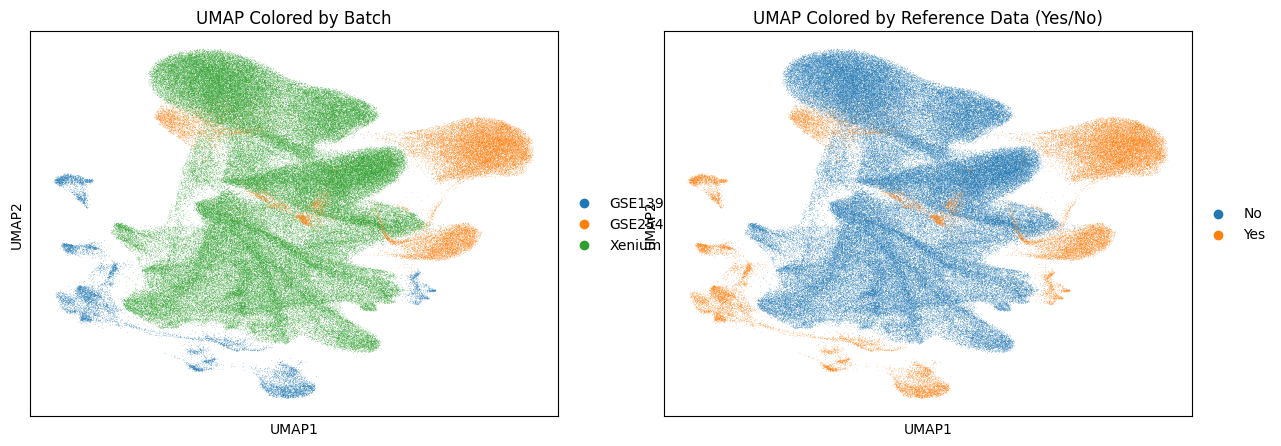

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot UMAP by batch identifier
sc.pl.umap(adata_concat, color="experiment_id", show=False, ax=axes[0])
axes[0].set_title("UMAP Colored by Batch")

# Plot UMAP by ref_data
sc.pl.umap(adata_concat, color="ref_data", show=False, ax=axes[1])
axes[1].set_title("UMAP Colored by Reference Data (Yes/No)")

plt.show()
plt.close()

## Train scVI model

In [29]:
adata_concat

AnnData object with n_obs × n_vars = 182485 × 471
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'experiment_id', 'ref_data', 'original_annotation', 'GSE', 'GSM', 'sample_number', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal', 'leiden', 'artifact', 'class', 'cell_type', 'cell_label', 'scanvi_batch'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout

In [30]:
# Check batch key
adata_concat.obs["experiment_id"] = adata_concat.obs["experiment_id"].astype("category")
adata_concat.obs["experiment_id"] = pd.Categorical(adata_concat.obs["experiment_id"])
adata_concat.obs['experiment_id'].value_counts()

experiment_id
Xenium       146276
GSE254789     25480
GSE139088     10729
Name: count, dtype: int64

In [31]:
scvi.model.SCVI.setup_anndata(
    adata_concat, 
    layer="counts", # use raw count data
    batch_key='experiment_id', # biggest batch effect is panel; 12/02 
)

model = scvi.model.SCVI(adata_concat, gene_likelihood="zinb") # gene_likelihood zinb added 12/2
print('starting model training')

model.train(early_stopping=True, 
            enable_progress_bar=True,
            accelerator = 'gpu'
           )

/home/workspace/environment/sc-charter/lib/python3.12/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


starting model training


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 44/44: 100%|██████████| 44/44 [09:13<00:00, 12.48s/it, v_num=1, train_loss_step=278, train_loss_epoch=221]

`Trainer.fit` stopped: `max_epochs=44` reached.


Epoch 44/44: 100%|██████████| 44/44 [09:13<00:00, 12.59s/it, v_num=1, train_loss_step=278, train_loss_epoch=221]


In [32]:
model.save(os.path.join(scvi_dir, '02_model') , prefix='02_label_transfer_')

In [33]:
SCVI_LATENT_KEY = "X_scVI_refalign"
adata_concat.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()

### Compute neighbors graph and UMAP

In [34]:
# neighbors
sc.pp.neighbors(adata_concat, use_rep="X_scVI_refalign", key_added='neighbors_scvi_refalign')
sc.tl.umap(adata_concat, neighbors_key='neighbors_scvi_refalign')

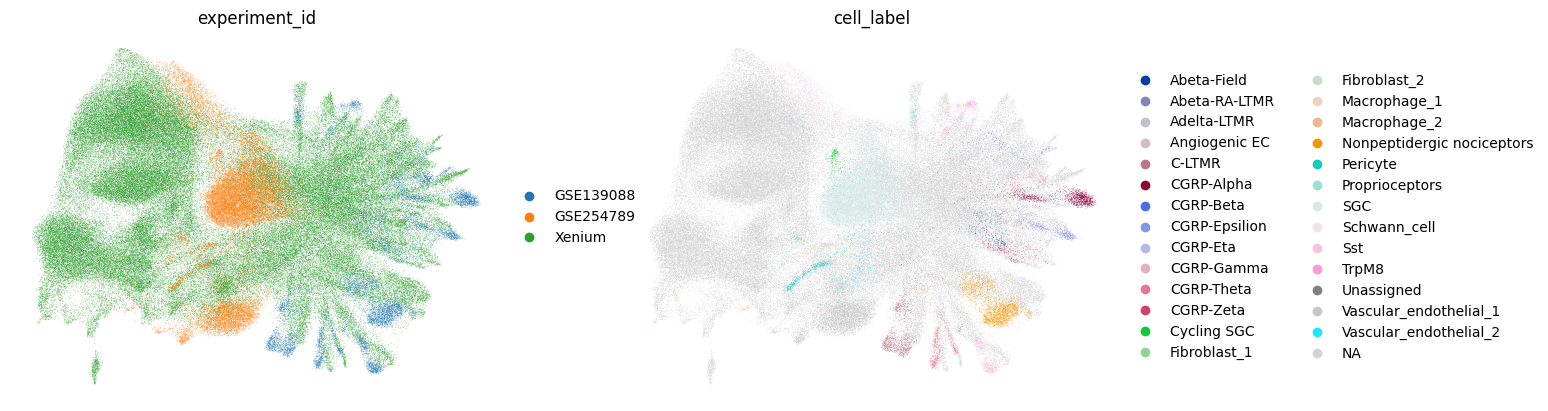

In [35]:
sc.pl.umap(adata_concat, color = ['experiment_id', 'cell_label'], frameon = False)

### Export refaligned adata

In [36]:
# save umap dims to csv
umap_df = pd.DataFrame(adata_concat.obsm['X_umap'], index=adata_concat.obs_names, columns=['umap1', 'umap2'])
filename = os.path.join(scanvi_dir, 'adata_scvi_refalign_umap_coords.csv')
umap_df.to_csv(filename)

In [37]:
filename = os.path.join(output_dir, 'adata_concat_scvi_refalign.h5ad')
os.makedirs(os.path.dirname(filename), exist_ok = True)

adata_concat.write_h5ad(filename, compression='gzip')

# Checkpoint

In [38]:
filename = os.path.join(output_dir, 'adata_concat_scvi_refalign.h5ad')
adata_concat = sc.read_h5ad(filename)
adata_concat

AnnData object with n_obs × n_vars = 182485 × 471
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'experiment_id', 'ref_data', 'original_annotation', 'GSE', 'GSM', 'sample_number', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal', 'leiden', 'artifact', 'class', 'cell_type', 'cell_label', 'scanvi_batch'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout

### Prep data for scANVI

In [39]:
adata_concat.obs.columns

Index(['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts',
       'control_probe_counts', 'genomic_control_counts',
       'control_codeword_counts', 'unassigned_codeword_counts',
       'deprecated_codeword_counts', 'total_counts', 'cell_area',
       'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id',
       'output_id', 'region_id', 'slide_id', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'log1p_total_counts',
       'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes',
       'doublet_scores', 'predicted_doublets', 'batch', '_scvi_batch',
       '_scvi_labels', 'leiden_scVI_1', 'experiment_id', 'ref_data',
       'original_annotation', 'GSE', 'GSM', 'sample_number', 'total_counts_mt',
       'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal',
       'leiden', 'artifact', 'class', 'cell_type', 'cell_label',
       'scanvi_batch'],
      dtype='object')

In [40]:
# Add 'Unknown' category for original samples if missing, then fill NaN
if 'Unknown' not in adata_concat.obs['cell_label'].cat.categories:
    adata_concat.obs['cell_label'] = adata_concat.obs['cell_label'].cat.add_categories('Unknown')

adata_concat.obs = adata_concat.obs.fillna(value={'cell_label': 'Unknown'})

In [41]:
adata_concat.obs['cell_label'].value_counts() # confirm that cell_label is the most granular

cell_label
Unknown                       146276
SGC                            15184
Vascular_endothelial_1          5007
Schwann_cell                    2697
Nonpeptidergic nociceptors      2669
CGRP-Alpha                      1440
C-LTMR                          1415
CGRP-Epsilion                    848
Sst                              757
CGRP-Theta                       735
CGRP-Gamma                       696
Pericyte                         605
TrpM8                            485
Vascular_endothelial_2           429
Macrophage_1                     401
Cycling SGC                      340
CGRP-Zeta                        321
Fibroblast_1                     282
Abeta-RA-LTMR                    265
CGRP-Eta                         257
Abeta-Field                      245
Proprioceptors                   228
Fibroblast_2                     207
Angiogenic EC                    182
Adelta-LTMR                      153
Macrophage_2                     146
CGRP-Beta                  

Below is important for mapping labels in the unintegrated original adata

In [42]:
# Subset only query dataset (unlabeled before scANVI training)
query_cells = adata_concat.obs["cell_label"] == "Unknown"
query_cells.to_csv(os.path.join(scanvi_dir, 'query_cells-subtype.csv'))
query_cells

aaagciof-1-0-0                        True
aaailodo-1-0-0                        True
aaanacfp-1-0-0                        True
aaaohjeo-1-0-0                        True
aabfmjal-1-0-0                        True
                                     ...  
GSM8057829_TTTGGAGAGTCGGGAT-1-1-1    False
GSM8057829_TTTGGAGTCCAAACCA-1-1-1    False
GSM8057829_TTTGGTTTCCAACCGG-1-1-1    False
GSM8057829_TTTGTTGTCCCTTTGG-1-1-1    False
GSM8057829_TTTGTTGTCCTAAACG-1-1-1    False
Name: cell_label, Length: 182485, dtype: bool

In [43]:
# fix barcodes; suffix was added during concat
query_cells_copy = query_cells.copy()
query_cells_copy.index = query_cells_copy.index.map(lambda x: x[:-2])
query_cells_copy

aaagciof-1-0                        True
aaailodo-1-0                        True
aaanacfp-1-0                        True
aaaohjeo-1-0                        True
aabfmjal-1-0                        True
                                   ...  
GSM8057829_TTTGGAGAGTCGGGAT-1-1    False
GSM8057829_TTTGGAGTCCAAACCA-1-1    False
GSM8057829_TTTGGTTTCCAACCGG-1-1    False
GSM8057829_TTTGTTGTCCCTTTGG-1-1    False
GSM8057829_TTTGTTGTCCTAAACG-1-1    False
Name: cell_label, Length: 182485, dtype: bool

## Run scANVI

In [44]:
# scanvi label transfer
scanvi_model = scvi.model.SCANVI.from_scvi_model(model, 
                                                 adata = adata_concat, 
                                                 unlabeled_category = 'Unknown', # Entries in labels_key to label
                                                 labels_key = 'cell_label') # Column to transfer labels from

#scanvi_model.train(max_epochs=20, 
#                   accelerator = 'gpu',
#                   n_samples_per_label = None) # this is longer training because it's not subsampling

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/workspace/environment/sc-charter/lib/python3.12/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


In [45]:
# Edited 12/02
scanvi_model.train(accelerator = 'gpu',
                   n_samples_per_label = None) # this is longer training because it's not subsampling

INFO     Training for 10 epochs.                                                                                   


Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 10/10: 100%|██████████| 10/10 [04:56<00:00, 29.81s/it, v_num=1, train_loss_step=273, train_loss_epoch=215]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 10/10: 100%|██████████| 10/10 [04:56<00:00, 29.65s/it, v_num=1, train_loss_step=273, train_loss_epoch=215]


In [46]:
# save scANVI model
scanvi_model.save(os.path.join(scvi_dir, '03_model_scanvi') , prefix='03_scanvi_')

### Reference mapping step

In [47]:
SCANVI_LATENT_KEY = "X_scANVI"
SCANVI_PREDICTION_KEY = "scanvi_labels"

adata_concat.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation(adata_concat)
adata_concat.obs[SCANVI_PREDICTION_KEY] = scanvi_model.predict(adata_concat) # this fills out the labels

In [48]:
adata_concat.obs['scanvi_labels'].value_counts()

scanvi_labels
SGC                           40978
Schwann_cell                  31818
Macrophage_2                  17799
Vascular_endothelial_1        12851
Nonpeptidergic nociceptors    10169
CGRP-Gamma                     8114
Fibroblast_2                   7085
CGRP-Alpha                     5071
Macrophage_1                   4851
Vascular_endothelial_2         4787
Fibroblast_1                   4640
C-LTMR                         4289
CGRP-Eta                       4167
Abeta-RA-LTMR                  4002
TrpM8                          3282
Pericyte                       2748
CGRP-Zeta                      2617
Sst                            2491
CGRP-Epsilion                  2328
CGRP-Theta                     2308
Adelta-LTMR                    1794
Abeta-Field                    1609
Proprioceptors                  916
Unassigned                      849
Cycling SGC                     448
Angiogenic EC                   286
CGRP-Beta                       188
Name: count, d

In [49]:
filename = os.path.join(output_dir, 'adata_concat-scvi-scanvi-predictions.h5ad')
os.makedirs(os.path.dirname(filename), exist_ok = True)

adata_concat.write_h5ad(filename, compression='gzip')

## Map query labels onto original adata

In [50]:
# re-read fresh adata with all the genes, this is the query
adata_query = sc.read_h5ad(os.path.join(adata_dir, 'adata-leiden-475.h5ad'))
adata_query.obs.head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,pct_counts_in_top_10_genes,pct_counts_in_top_20_genes,pct_counts_in_top_50_genes,pct_counts_in_top_150_genes,doublet_scores,predicted_doublets,batch,_scvi_batch,_scvi_labels,leiden_scVI_1
aaagciof-1-0,aaagciof-1,634.049133,299.172485,347,0,0,0,0,0,347.0,...,29.106628,46.974063,74.351585,100.000000,0.053711,False,0,1,0,19
aaailodo-1-0,aaailodo-1,609.569763,308.822144,2415,0,0,0,0,0,2415.0,...,34.492754,52.091097,77.060041,98.053830,0.056738,False,0,1,0,10
aaanacfp-1-0,aaanacfp-1,634.638367,309.968719,1937,0,0,0,0,0,1937.0,...,36.964378,55.962829,83.840991,99.690243,0.061728,False,0,1,0,19
aaaohjeo-1-0,aaaohjeo-1,627.379822,297.124298,479,0,0,0,0,0,479.0,...,33.611691,49.686848,73.277662,100.000000,0.041356,False,0,1,0,7
aabfmjal-1-0,aabfmjal-1,621.577148,367.691040,402,0,0,0,0,0,402.0,...,47.761194,61.691542,82.338308,100.000000,0.030748,False,0,1,0,10


In [51]:
# create adata_labeled from adata_concat which has the labels
adata_labeled = adata_concat[adata_concat.obs['scanvi_batch'] == '0'].copy() # batch is stored as string

print(adata_labeled.obs['scanvi_batch'].value_counts())
print('')
print(adata_labeled.obs['output_id'].value_counts())

scanvi_batch
0    146276
Name: count, dtype: int64

output_id
output-XETG00123__0052281__TMA00305__20251108__004334    32361
output-XETG00123__0052334__TMA00306__20251108__004334    31535
output-XETG00123__0052334__TMA00304__20251108__004334    21020
output-XETG00123__0052046__TMA00311__20251119__221941    19336
output-XETG00123__0052399__TMA00312__20251119__221941    17302
output-XETG00123__0052281__TMA00303__20251108__004334    11122
output-XETG00123__0052046__TMA00307__20251119__221941     6835
output-XETG00123__0052399__TMA00308__20251119__221941     6765
Name: count, dtype: int64


In [52]:
# Remove suffix from labeled adata subset from adata_concat
adata_labeled.obs.index = adata_labeled.obs.index.astype(str)
adata_labeled.obs.index = adata_labeled.obs.index.str[:-2]
adata_labeled.obs.head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,pct_counts_mt,total_counts_ribosomal,pct_counts_ribosomal,leiden,artifact,class,cell_type,cell_label,scanvi_batch,scanvi_labels
aaagciof-1-0,aaagciof-1,634.049133,299.172485,347.0,0.0,0.0,0.0,0.0,0.0,344.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,0,Adelta-LTMR
aaailodo-1-0,aaailodo-1,609.569763,308.822144,2415.0,0.0,0.0,0.0,0.0,0.0,2396.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,0,Abeta-RA-LTMR
aaanacfp-1-0,aaanacfp-1,634.638367,309.968719,1937.0,0.0,0.0,0.0,0.0,0.0,1928.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,0,Adelta-LTMR
aaaohjeo-1-0,aaaohjeo-1,627.379822,297.124298,479.0,0.0,0.0,0.0,0.0,0.0,474.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,0,SGC
aabfmjal-1-0,aabfmjal-1,621.577148,367.691040,402.0,0.0,0.0,0.0,0.0,0.0,399.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,0,Abeta-RA-LTMR


In [53]:
# fix barcodes; suffix was added during concat
#query_cells_copy = query_cells.copy()
#query_cells_copy.index = query_cells_copy.index.map(lambda x: x[:-2])

In [54]:
#  Clean up query_cells_copy
## check it's a list of valid cell IDs that exist in both AnnData objects

if isinstance(query_cells_copy, pd.Series) and query_cells_copy.dtype == bool:
    query_cells_copy = query_cells_copy[query_cells_copy].index.tolist()

# Restrict to intersection of cell IDs in both datasets
query_cells_copy = [c for c in query_cells_copy if c in adata_labeled.obs_names and c in adata_query.obs_names]

print(f"{len(query_cells_copy)} overlapping cells between labeled and query datasets.")

146276 overlapping cells between labeled and query datasets.


In [55]:
# Transfer predictions back to the original query dataset
adata_query.obs.loc[query_cells_copy, 'scanvi_labels'] = adata_labeled.obs.loc[query_cells_copy, "scanvi_labels"]
adata_query.obs['scanvi_labels']

aaagciof-1-0               Adelta-LTMR
aaailodo-1-0             Abeta-RA-LTMR
aaanacfp-1-0               Adelta-LTMR
aaaohjeo-1-0                       SGC
aabfmjal-1-0             Abeta-RA-LTMR
                         ...          
oiijogbo-1-7                CGRP-Alpha
oijefoep-1-7                       SGC
oilegbah-1-7                     TrpM8
oilfilnk-1-7                       SGC
oilnmaia-1-7    Vascular_endothelial_1
Name: scanvi_labels, Length: 146276, dtype: category
Categories (27, object): ['Abeta-Field', 'Abeta-RA-LTMR', 'Adelta-LTMR', 'Angiogenic EC', ..., 'TrpM8', 'Unassigned', 'Vascular_endothelial_1', 'Vascular_endothelial_2']

In [56]:
adata_query.obs.scanvi_labels.value_counts()

scanvi_labels
Schwann_cell                  29178
SGC                           25707
Macrophage_2                  17655
Vascular_endothelial_1         7810
Nonpeptidergic nociceptors     7500
CGRP-Gamma                     7412
Fibroblast_2                   6881
Macrophage_1                   4452
Vascular_endothelial_2         4383
Fibroblast_1                   4360
CGRP-Eta                       3909
Abeta-RA-LTMR                  3733
CGRP-Alpha                     3635
C-LTMR                         2878
TrpM8                          2798
CGRP-Zeta                      2292
Pericyte                       2146
Sst                            1734
Adelta-LTMR                    1642
CGRP-Theta                     1575
CGRP-Epsilion                  1479
Abeta-Field                    1365
Unassigned                      769
Proprioceptors                  689
Cycling SGC                     128
Angiogenic EC                   110
CGRP-Beta                        56
Name: count, d

## Export labeled adata

In [57]:
h5ad_path = os.path.join(output_dir, 'adata-scanvi-labels.h5ad')
adata_query.write_h5ad(h5ad_path, compression='gzip')

print(h5ad_path)

/home/workspace/projects/drg/data/h5ad/export_03/03a_scanvi/adata-scanvi-labels.h5ad


## Session info

In [58]:
print('active IDE: sc-spatial-gpu')
print('active conda environment: ', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-spatial-gpu
active conda environment:  sc-charter


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


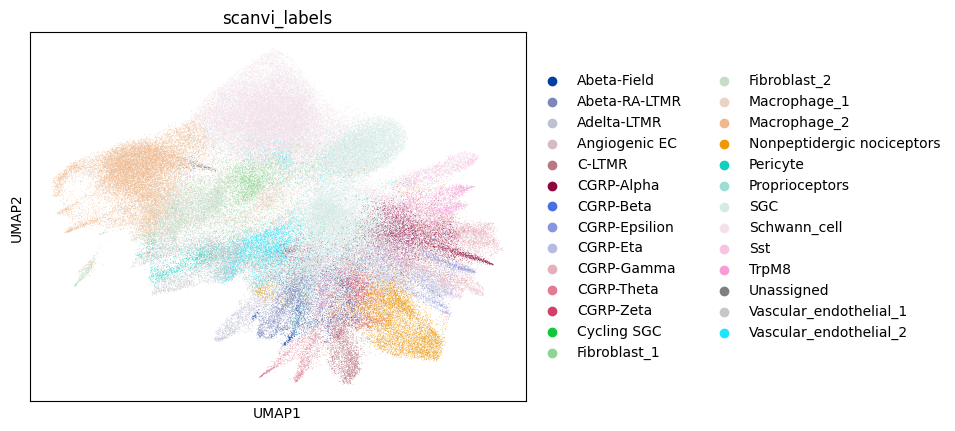

In [59]:
sc.pl.umap(adata_query, color = 'scanvi_labels')

In [60]:
adata_query

AnnData object with n_obs × n_vars = 146276 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'scanvi_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI_1', 'leiden_scVI_1_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'sample_id_colors', 'slide_id_colors', 'umap', 'scanvi_labels_colors'
    obsm: 'X_scVI_ModelA_475', 'X_umap', 'spatial'
    layers: 'counts', 'log1p', 'normalized'
    obsp: 

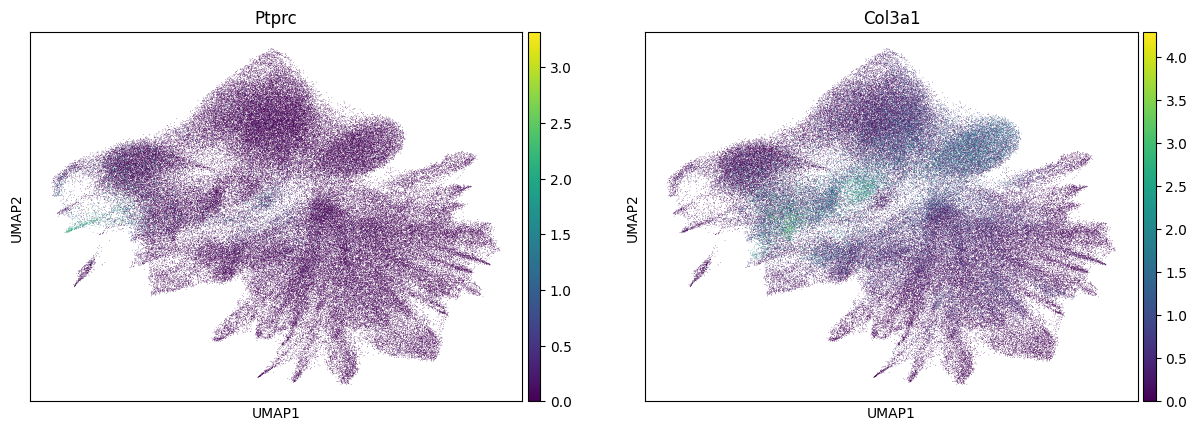

In [61]:
sc.pl.umap(adata_query, color = ['Ptprc', 'Col3a1'])

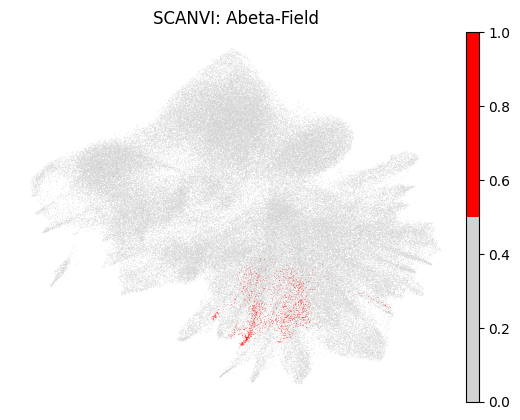

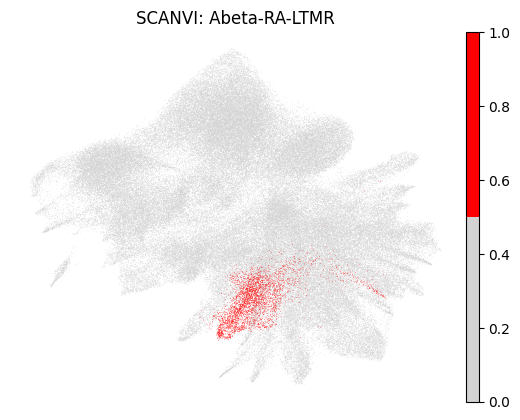

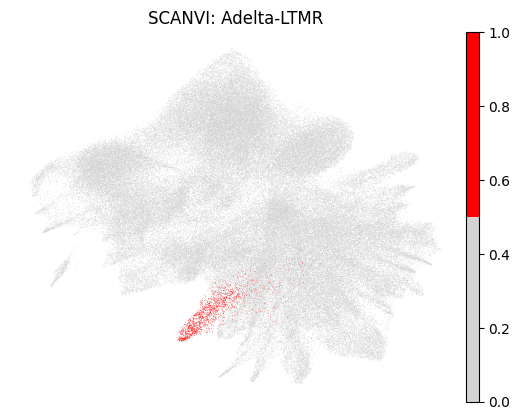

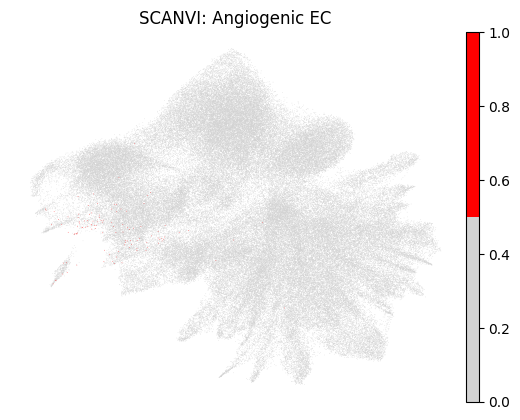

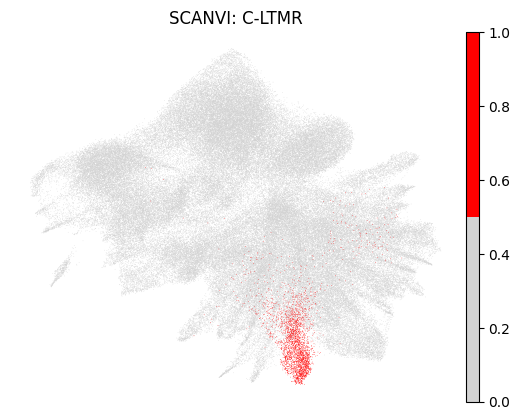

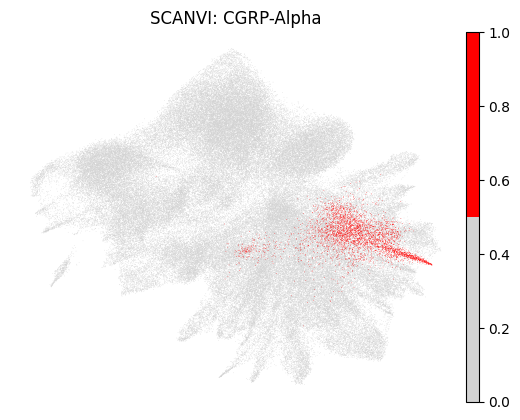

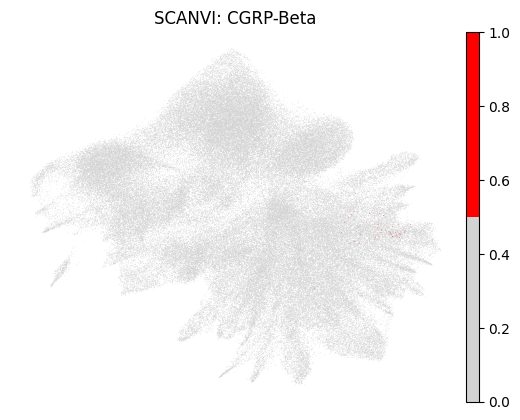

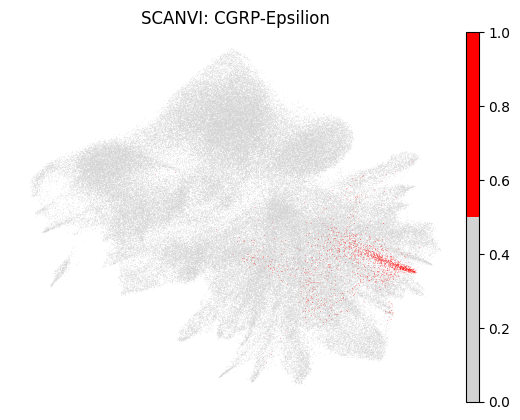

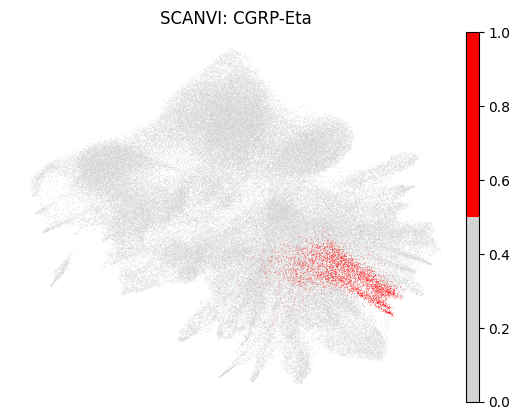

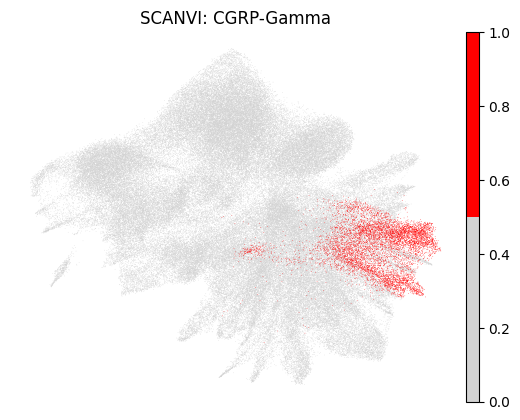

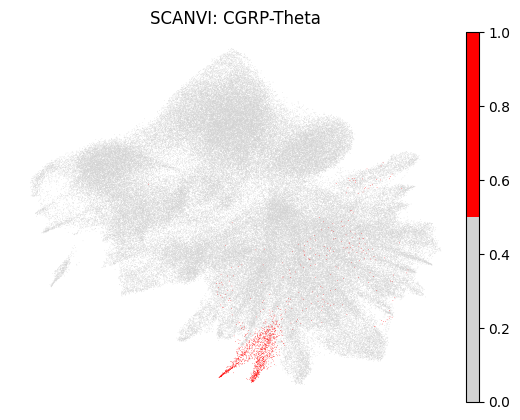

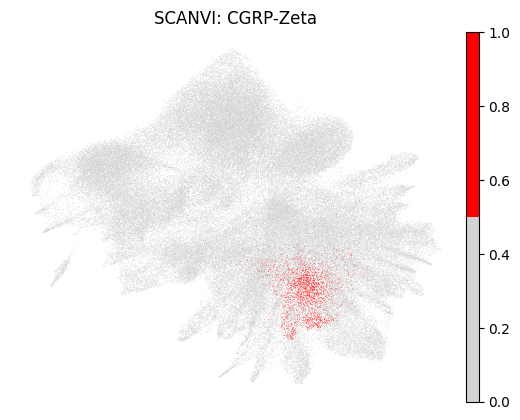

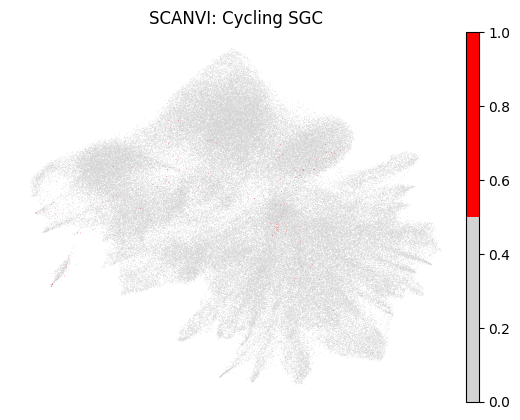

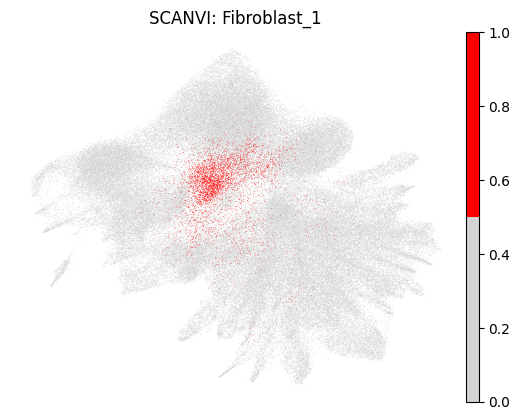

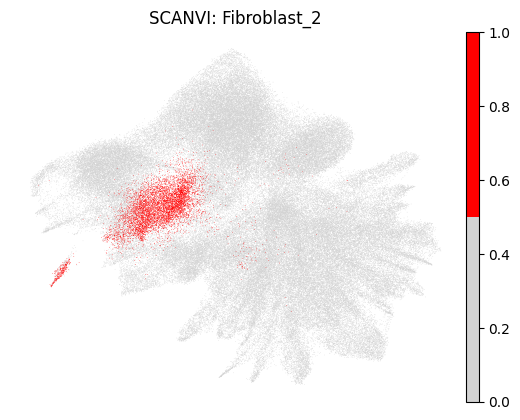

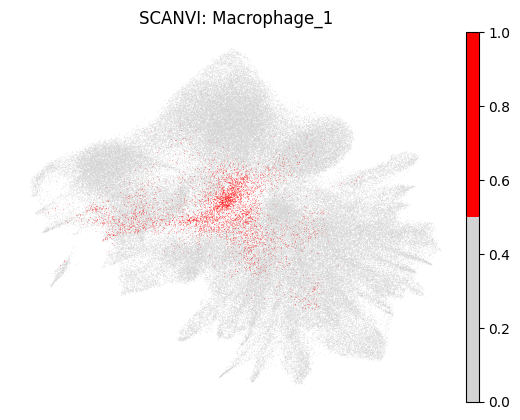

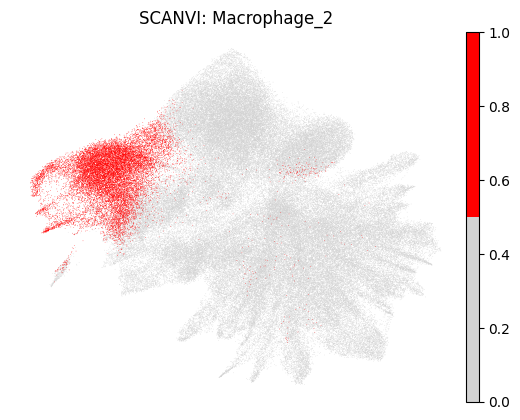

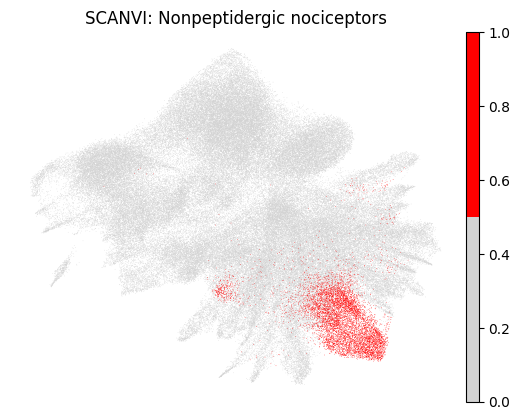

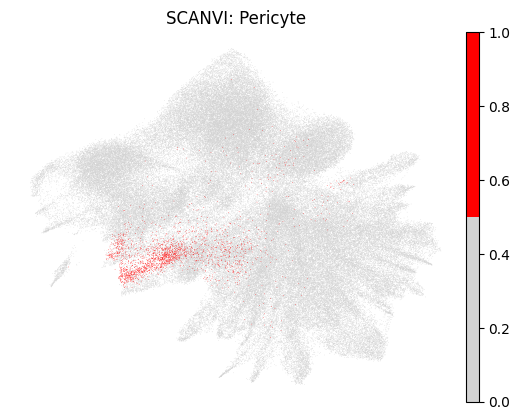

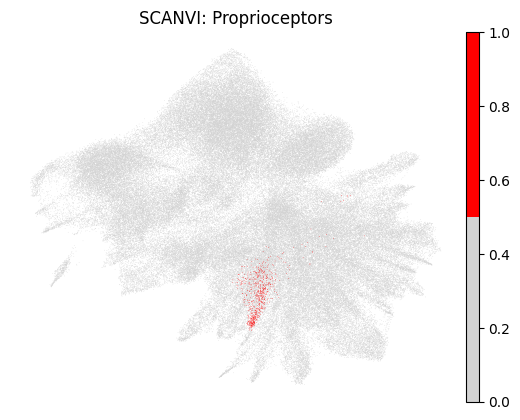

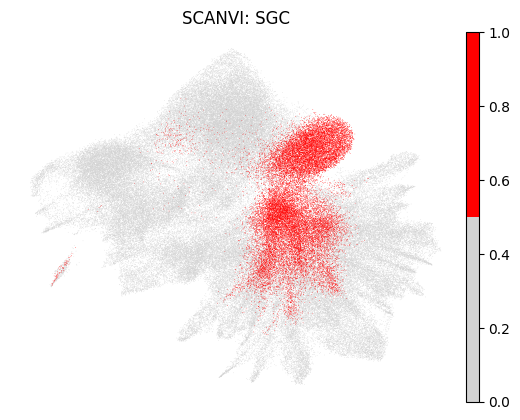

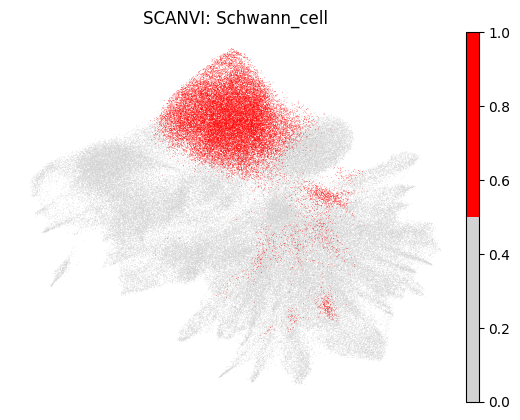

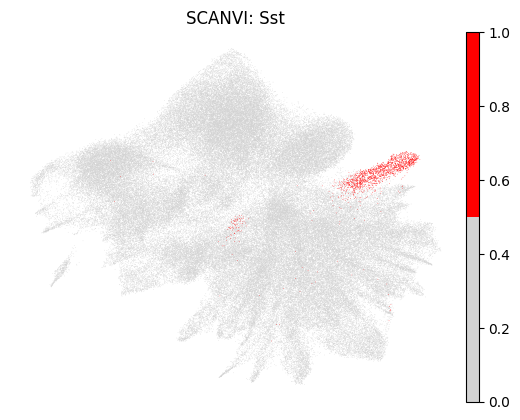

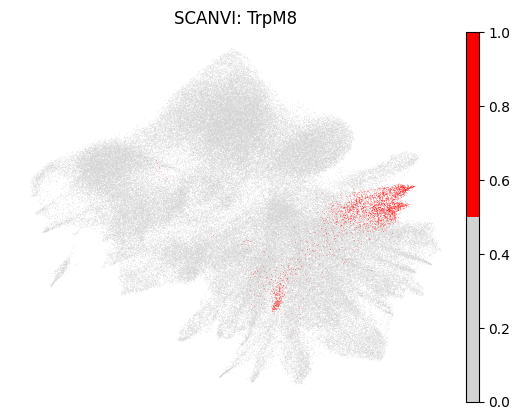

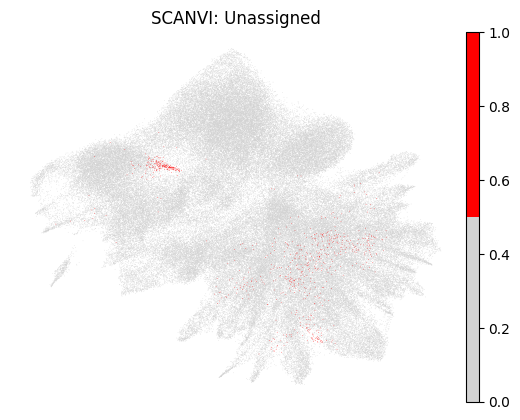

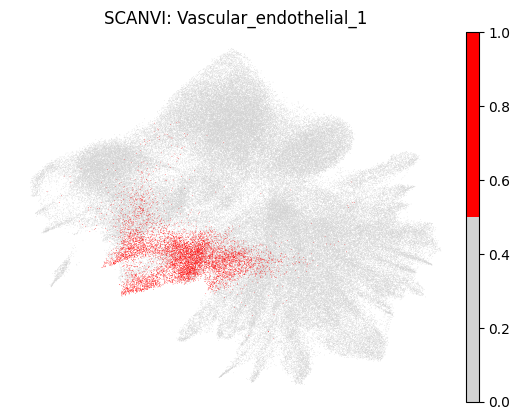

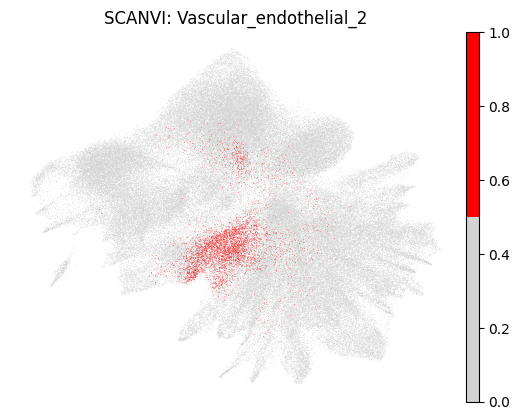

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

red_gray_cmap = ListedColormap(["lightgray", "red"])

for label in adata_query.obs["scanvi_labels"].cat.categories:

    # Create a binary mask: 1 for highlighted cells, 0 for all others
    adata_query.obs["highlight"] = (adata_query.obs["scanvi_labels"] == label).astype(int)

    sc.pl.umap(
        adata_query,
        color="highlight",
        cmap=red_gray_cmap,            # <--- THIS WORKS
        vmin=0, vmax=1,                # ensures correct mapping
        frameon=False,
        title=f"SCANVI: {label}",
        show=True
    )

In [66]:
# ---------------------------------------------
# 1. Barcode prefixes (without suffixes)
# ---------------------------------------------
prefixes = [
    "apeeemip", "bpoikicj", "cbhmmeof", "akcoadof", "bgmdeeeb",
    "hjjgalia", "hjjkhdhk", "mnhcfodp", "bmjgagok", "ijnggkoc",
    "llknggjo", "llmfnafp", "llmgffik"
]

# ---------------------------------------------
# 2. Find matching cells using .startswith()
# ---------------------------------------------
matches = [
    bc for bc in adata_query.obs_names
    if any(bc.startswith(p) for p in prefixes)
]

print("Matched barcodes:")
print(matches)

# ---------------------------------------------
# 3. Extract SCANVI + Leiden annotations
# ---------------------------------------------
result = adata_query.obs.loc[matches, ["scanvi_labels", "leiden_scVI_1"]]

print("\nSCANVI + Leiden for matched barcodes:")
print(result)

Matched barcodes:
['apeeemip-1-1', 'bpoikicj-1-1', 'cbhmmeof-1-1', 'akcoadof-1-2', 'bgmdeeeb-1-2', 'hjjgalia-1-2', 'hjjkhdhk-1-2', 'mnhcfodp-1-2', 'bmjgagok-1-3', 'ijnggkoc-1-3', 'llknggjo-1-3', 'llmfnafp-1-3', 'llmgffik-1-3']

SCANVI + Leiden for matched barcodes:
                       scanvi_labels leiden_scVI_1
apeeemip-1-1  Vascular_endothelial_1            17
bpoikicj-1-1              CGRP-Gamma            10
cbhmmeof-1-1              CGRP-Gamma            10
akcoadof-1-2              CGRP-Gamma            10
bgmdeeeb-1-2              CGRP-Gamma            10
hjjgalia-1-2              CGRP-Gamma            10
hjjkhdhk-1-2              CGRP-Gamma            10
mnhcfodp-1-2              CGRP-Gamma            10
bmjgagok-1-3              CGRP-Gamma            10
ijnggkoc-1-3              CGRP-Gamma            10
llknggjo-1-3              CGRP-Gamma             6
llmfnafp-1-3              CGRP-Gamma            10
llmgffik-1-3              CGRP-Gamma            10


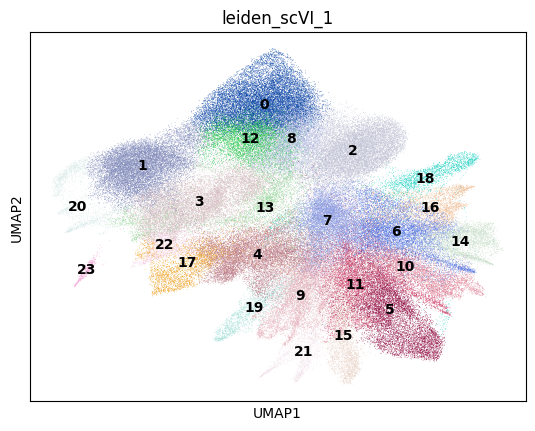

In [67]:
sc.pl.umap(adata_query, color = 'leiden_scVI_1', legend_loc = 'on data')

Number of matched cells = 13


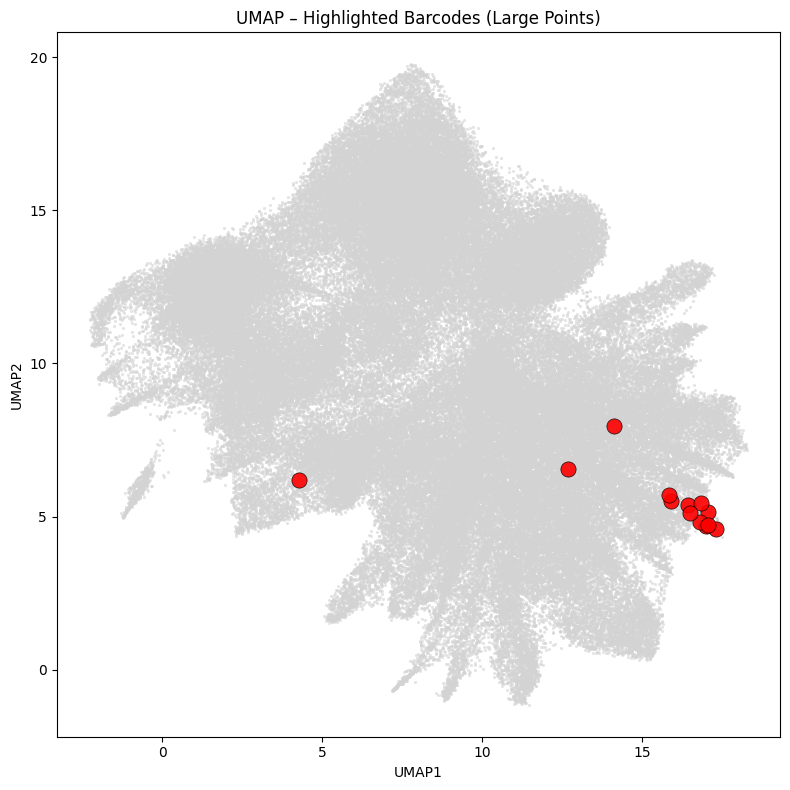

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------
# 1. Barcode prefixes
# -------------------------------------------------------
prefixes = [
    "apeeemip", "bpoikicj", "cbhmmeof", "akcoadof", "bgmdeeeb",
    "hjjgalia", "hjjkhdhk", "mnhcfodp", "bmjgagok", "ijnggkoc",
    "llknggjo", "llmfnafp", "llmgffik"
]

# -------------------------------------------------------
# 2. Boolean mask for barcode matches
# -------------------------------------------------------
mask = np.array([any(name.startswith(p) for p in prefixes)
                 for name in adata_query.obs_names])

matched = adata_query[mask]
background = adata_query[~mask]

print("Number of matched cells =", mask.sum())

# -------------------------------------------------------
# 3. Extract UMAP coordinates
# -------------------------------------------------------
umap_all = adata_query.obsm["X_umap"]
umap_bg  = background.obsm["X_umap"]
umap_hit = matched.obsm["X_umap"]

# -------------------------------------------------------
# 4. Plot manually with matplotlib for control over size
# -------------------------------------------------------
plt.figure(figsize=(8, 8))

# Background cells (small, gray)
plt.scatter(
    umap_bg[:, 0], umap_bg[:, 1],
    s=5, c="lightgray", alpha=0.6, linewidths=0
)

# Highlighted barcodes (BIG, red)
plt.scatter(
    umap_hit[:, 0], umap_hit[:, 1],
    s=120, c="red", alpha=0.9, linewidths=0.5, edgecolors="black"
)

plt.title("UMAP – Highlighted Barcodes (Large Points)")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.tight_layout()
plt.show()